# ─── Ali4Concrete Nexus: Data-Driven Concrete Mix Design ───
### *Engineering Certainty Beyond Laboratory Illusions*

**Ali Abdulameer Mohammed** *Computational Civil Engineer | Materials Data Analyst | R&D in Data-Driven Concrete Mix Design* ## 🛠️ The Philosophy: "The Standard... As It Should Be."
A 40 MPa laboratory report can often become an **engineering illusion** when it fails to survive the harsh environmental realities, extreme execution variables, and mass effect temperatures of the construction site. Traditional labs print isolated numbers; **Ali4Concrete** delivers risk-managed, computational concrete engineering to transition mega-projects from blind guesswork to absolute engineering certainty.

Our proprietary **Data-Driven Concrete Mix Design (DDCMD)** methodology is strictly anchored on **4 Core Pillars**:
1. **Physics-First Approach (Material Sciences):** Analyzing the thermodynamics, micro-structural mechanics, and hydration kinetics of cementitious matrices.
2. **Strict Compliance:** Zero-compromise application of standard ASTM and ACI specifications to eliminate on-site chaos.
3. **Computational Analysis:** Leveraging modern data science libraries (Python, Pandas, NumPy, Scikit-Learn, XGBoost) to uncover hidden material interactions.
4. **Field-Ready Interpretation:** Translating abstract laboratory metrics into decisive, highly actionable strategies on-site.

---

## 🌐 Connect & Collaborate
* **Website:** [aliabdulameer.me](https://aliabdulameer.me)
* **Email:** info@aliabdulameer.me
* **GitHub Organization:** [github.com/Ali4Concrete](https://github.com/Ali4Concrete)
* **YouTube Channel:** [@Ali4Concrete](https://youtube.com/@Ali4Concrete)

---

# 📈 ACI 214R Statistical Strength Analyzer & Target Mix Optimizer
### *Zero-Code Historical Data Mining for Concrete Quality Control*

## 🎯 Introduction & Objective
This notebook serves as an advanced, automated computational engine designed for concrete technologists, QA/QC managers, and structural consultants. It shifts the paradigm of compressive strength evaluation from a passive "pass/fail" archiving task into proactive, mathematical quality control. By implementing the rigorous statistical frameworks of **ACI 214R-11** and **ACI 318M**, this engine transforms raw, chaotic historical site data into a strategic gold mine for mix optimization.

## 💡 Engineering & Economic Contribution
In traditional construction management, concrete compressive strength is treated merely as a structural acceptance criterion. However, high variability (Standard Deviation) in test results is an invisible financial and technical drain. Uncontrolled variance forces engineers to rely on "blind guesswork" and over-design mixtures, demanding an excessive volume of expensive cement (kg/m³) to guarantee minimum strength. This over-design causes:
* **Massive Financial Waste:** Cement is the most costly component per cubic meter.
* **Elevated Heat of Hydration:** Triggering severe thermal cracking, especially in mass concrete and extreme weather environments.
* **Compromised Durability:** Increased cement paste volume can lead to higher shrinkage, micro-cracking, and reduced long-term structural resilience.

### 🚀 How this Notebook Optimizes Your Project:
* **Zero-Programming Interface:** Simply input your daily QA/QC cylinder test records. The algorithm handles the complex statistics.
* **Automated ACI 214R Evaluation:** Instantly calculates both *Overall Variation* (batch-to-batch consistency) and *Within-Test Variation* (laboratory testing precision) to instantly flag whether the issue lies in the plant production or the lab technicians.
* **Target Strength ($f'_{cr}$) Optimization:** Mathematically calculates the exact, reduced required average strength based on your proven historical standard deviation (ACI 318M), legally and safely lowering cement content.
* **Advanced CUSUM & Moving Average Control Charts:** visualizes data trends to detect "Special Causes" (like sudden shifts in aggregate sources or cement chemistry) long before they result in a failing cylinder break on-site.

By executing this notebook continuously throughout the project lifecycle, you mathematically compress variance, radically reduce cement waste, control thermal behavior, and ensure sustainable constructability under extreme execution environments.

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# --- Ali4Concrete Brand Palette (Industrial Luxury) ---
BRAND_NAVY = '#081c3a'  # Deep structural navy
BRAND_GOLD = '#d4af37'  # Matte gold for targets
BRAND_IVORY = '#fdfbf7' # Ivory white for background
BRAND_RED = '#8b0000'   # Alert red for control limits
BRAND_GREY = '#7f8c8d'  # Slate grey for historical data

# --- High-Resolution Matplotlib Configurations ---
plt.rcParams['figure.facecolor'] = BRAND_IVORY
plt.rcParams['axes.facecolor'] = BRAND_IVORY
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = BRAND_NAVY
plt.rcParams['text.color'] = BRAND_NAVY
plt.rcParams['axes.labelcolor'] = BRAND_NAVY
plt.rcParams['xtick.color'] = BRAND_NAVY
plt.rcParams['ytick.color'] = BRAND_NAVY

In [15]:
# [Markdown]
# ## 2. Data Ingestion Protocol (CSV Loader)
# This module strictly reads from an external dataset (e.g., QA/QC lab reports). 
# If the target CSV file does not exist in the directory, the engine will automatically 
# generate a highly realistic template containing 150 historical data points. 
# The Engineer can later replace this template with their actual site records.

FILE_NAME = 'QAQC_Concrete_Test_Records.csv'

def ensure_data_exists(file_path):
    if not os.path.exists(file_path):
        print(f"⚠️ Data file '{file_path}' not found. Generating a standard template...")
        np.random.seed(101)
        # Expanding dataset to 150 points for realistic long-term project representation
        base_strength = np.random.normal(loc=46.0, scale=3.5, size=150)
        
        # Simulating testing error (Within-Test Variation)
        cyl_1 = base_strength + np.random.normal(0, 1.2, 150)
        cyl_2 = base_strength + np.random.normal(0, 1.2, 150)
        
        df_template = pd.DataFrame({
            'Test_ID': range(1, 151),
            'Date': pd.date_range(start='2025-01-01', periods=150, freq='D'),
            'Cylinder_1_MPa': np.round(cyl_1, 1),
            'Cylinder_2_MPa': np.round(cyl_2, 1)
        })
        df_template.to_csv(file_path, index=False)
        print(f"✅ Template '{file_path}' successfully generated and ready for engineer inputs.")
    else:
        print(f"✅ Concrete test records loaded successfully from '{file_path}'.")

ensure_data_exists(FILE_NAME)

# Load the data from the CSV file
df_concrete = pd.read_csv(FILE_NAME)

⚠️ Data file 'QAQC_Concrete_Test_Records.csv' not found. Generating a standard template...
✅ Template 'QAQC_Concrete_Test_Records.csv' successfully generated and ready for engineer inputs.


In [17]:
# [Markdown]
# ## 3. The DDCMD Computational Engine (ACI 214R & 318M)
# This class strictly encapsulates the ACI statistical framework to compute Overall Variation, 
# Within-Test Precision, and Target Optimization, then renders the executive dashboards.

class ACI214Engine:
    def __init__(self, data, fc_specified):
        self.df = data.copy()
        self.fc = fc_specified
        self.analyze()
        
    def analyze(self):
        # Calculate Test Results (Average of 2 cylinders per ACI 214R)
        self.df['Test_Result_MPa'] = self.df[['Cylinder_1_MPa', 'Cylinder_2_MPa']].mean(axis=1)
        self.df['Range_MPa'] = abs(self.df['Cylinder_1_MPa'] - self.df['Cylinder_2_MPa'])
        
        # 1. Overall Variation (Batch-to-Batch)
        self.mean_X = self.df['Test_Result_MPa'].mean()
        self.std_overall = self.df['Test_Result_MPa'].std(ddof=1)
        
        # 2. Within-Test Variation (Lab Precision)
        # Using ACI 214R Table 7.5 limits[cite: 1]
        self.mean_R = self.df['Range_MPa'].mean()
        self.std_within = self.mean_R / 1.128  # d2 factor for n=2
        # Upper Control Limit for Range (UCL_R) = D4 * R_bar (For n=2, D4 = 3.27)[cite: 1]
        self.ucl_r = 3.27 * self.mean_R 
        
        # 3. Target Strength Optimization (ACI 318M)
        fcr_1 = self.fc + 1.34 * self.std_overall
        fcr_2 = 0.90 * self.fc + 2.33 * self.std_overall
        self.fcr_opt = max(fcr_1, fcr_2)
        
        # 4. Moving Average (Trend Analysis)
        self.df['Moving_Avg_5'] = self.df['Test_Result_MPa'].rolling(window=5).mean()

    def render_dashboards(self):
        fig, axes = plt.subplots(3, 1, figsize=(16, 20))
        fig.patch.set_facecolor(BRAND_IVORY)
        
        # ---------------------------------------------------------
        # CHART 1: Normal Distribution (Bell Curve) & Optimization
        # ---------------------------------------------------------
        ax1 = axes[0]
        x = np.linspace(self.mean_X - 4*self.std_overall, self.mean_X + 4*self.std_overall, 200)
        y = stats.norm.pdf(x, self.mean_X, self.std_overall)
        
        ax1.plot(x, y, color=BRAND_NAVY, linewidth=2.5)
        ax1.fill_between(x, y, color=BRAND_NAVY, alpha=0.1)
        ax1.hist(self.df['Test_Result_MPa'], bins=20, density=True, alpha=0.6, color=BRAND_GREY, edgecolor=BRAND_NAVY)
        
        ax1.axvline(self.fcr_opt, color=BRAND_GOLD, linestyle='--', linewidth=3, label=f"Optimized Target (f'cr): {self.fcr_opt:.1f} MPa")
        ax1.axvline(self.fc, color=BRAND_RED, linestyle='-', linewidth=2, label=f"Specified Strength (f'c): {self.fc:.1f} MPa")
        ax1.axvline(self.mean_X, color=BRAND_NAVY, linestyle='-.', linewidth=1.5, label=f"Production Mean: {self.mean_X:.1f} MPa")
        
        ax1.set_title("1. Overall Variation & Target Mix Optimization (Thermodynamic Savings)", fontsize=16, fontweight='bold', pad=15)
        ax1.set_xlabel("Compressive Strength (MPa)", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Probability Density", fontsize=12, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=12, frameon=True, facecolor=BRAND_IVORY, edgecolor=BRAND_NAVY)
        ax1.grid(True, linestyle=':', alpha=0.5)

        # ---------------------------------------------------------
        # CHART 2: Moving Average Control Chart (Special Causes)
        # ---------------------------------------------------------
        ax2 = axes[1]
        ax2.plot(self.df.index, self.df['Test_Result_MPa'], marker='o', markersize=5, linestyle='', color=BRAND_GREY, alpha=0.5, label='Individual Batch Result')
        ax2.plot(self.df.index, self.df['Moving_Avg_5'], color=BRAND_NAVY, linewidth=3, label='5-Batch Moving Average (Trend Indicator)')
        
        ax2.axhline(self.fcr_opt, color=BRAND_GOLD, linestyle='--', linewidth=2.5, label="Optimized Target (f'cr)")
        ax2.axhline(self.fc, color=BRAND_RED, linestyle='-', linewidth=2, label="Specified Strength (f'c)")
        
        ax2.set_title("2. Production Control Chart: Moving Average (Proactive Trend Detection)", fontsize=16, fontweight='bold', pad=15)
        ax2.set_xlabel("Test Number (Chronological)", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Compressive Strength (MPa)", fontsize=12, fontweight='bold')
        ax2.legend(loc='lower right', fontsize=12, frameon=True, facecolor=BRAND_IVORY, edgecolor=BRAND_NAVY)
        ax2.grid(True, linestyle=':', alpha=0.5)

        # ---------------------------------------------------------
        # CHART 3: Range Control Chart (Lab Testing Precision)
        # ---------------------------------------------------------
        ax3 = axes[2]
        ax3.plot(self.df.index, self.df['Range_MPa'], marker='o', markersize=6, linestyle='-', color=BRAND_NAVY, alpha=0.7, label='Within-Test Range (Cyl_A vs Cyl_B)')
        
        ax3.axhline(self.mean_R, color=BRAND_GOLD, linestyle='--', linewidth=2, label=f"Average Range (R̄): {self.mean_R:.2f} MPa")
        ax3.axhline(self.ucl_r, color=BRAND_RED, linestyle='-', linewidth=3, label=f"Maximum Allowable Range (Action Limit): {self.ucl_r:.2f} MPa")
        
        ax3.set_title("3. Range Control Chart: Laboratory Precision Assessment (ACI 214R)", fontsize=16, fontweight='bold', pad=15)
        ax3.set_xlabel("Test Number (Chronological)", fontsize=12, fontweight='bold')
        ax3.set_ylabel("Strength Difference (MPa)", fontsize=12, fontweight='bold')
        ax3.legend(loc='upper right', fontsize=12, frameon=True, facecolor=BRAND_IVORY, edgecolor=BRAND_NAVY)
        
        # Highlight Out-of-Control points in red
        out_of_control = self.df[self.df['Range_MPa'] > self.ucl_r]
        if not out_of_control.empty:
            ax3.plot(out_of_control.index, out_of_control['Range_MPa'], 'ro', markersize=10, label='Lab Error (Out of Control)')
            ax3.annotate('Investigate Ninja Lab Practices!', 
                         xy=(out_of_control.index[0], out_of_control['Range_MPa'].iloc[0]),
                         xytext=(out_of_control.index[0]-10, out_of_control['Range_MPa'].iloc[0]+1),
                         arrowprops=dict(facecolor=BRAND_RED, shrink=0.05),
                         fontsize=12, fontweight='bold', color=BRAND_RED)

        ax3.grid(True, linestyle=':', alpha=0.5)

        # Render Final
        plt.tight_layout(pad=4.0)
        plt.show()
        
        print("\n" + "="*70)
        print("💡 EXECUTIVE SUMMARY (Engineering Certainty):")
        print("="*70)
        print(f"✔️ Overall Production Standard Deviation (Sc) : {self.std_overall:.2f} MPa")
        print(f"✔️ Lab Precision Standard Deviation (S1)      : {self.std_within:.2f} MPa")
        print(f"✔️ Optimized Target Strength (f'cr)           : {self.fcr_opt:.2f} MPa")
        if not out_of_control.empty:
            print(f"❌ WARNING: {len(out_of_control)} test(s) exceeded the Maximum Allowable Range limit.")
            print("   Action: Investigate curing conditions, capping, or machine calibration.")
        print("="*70)

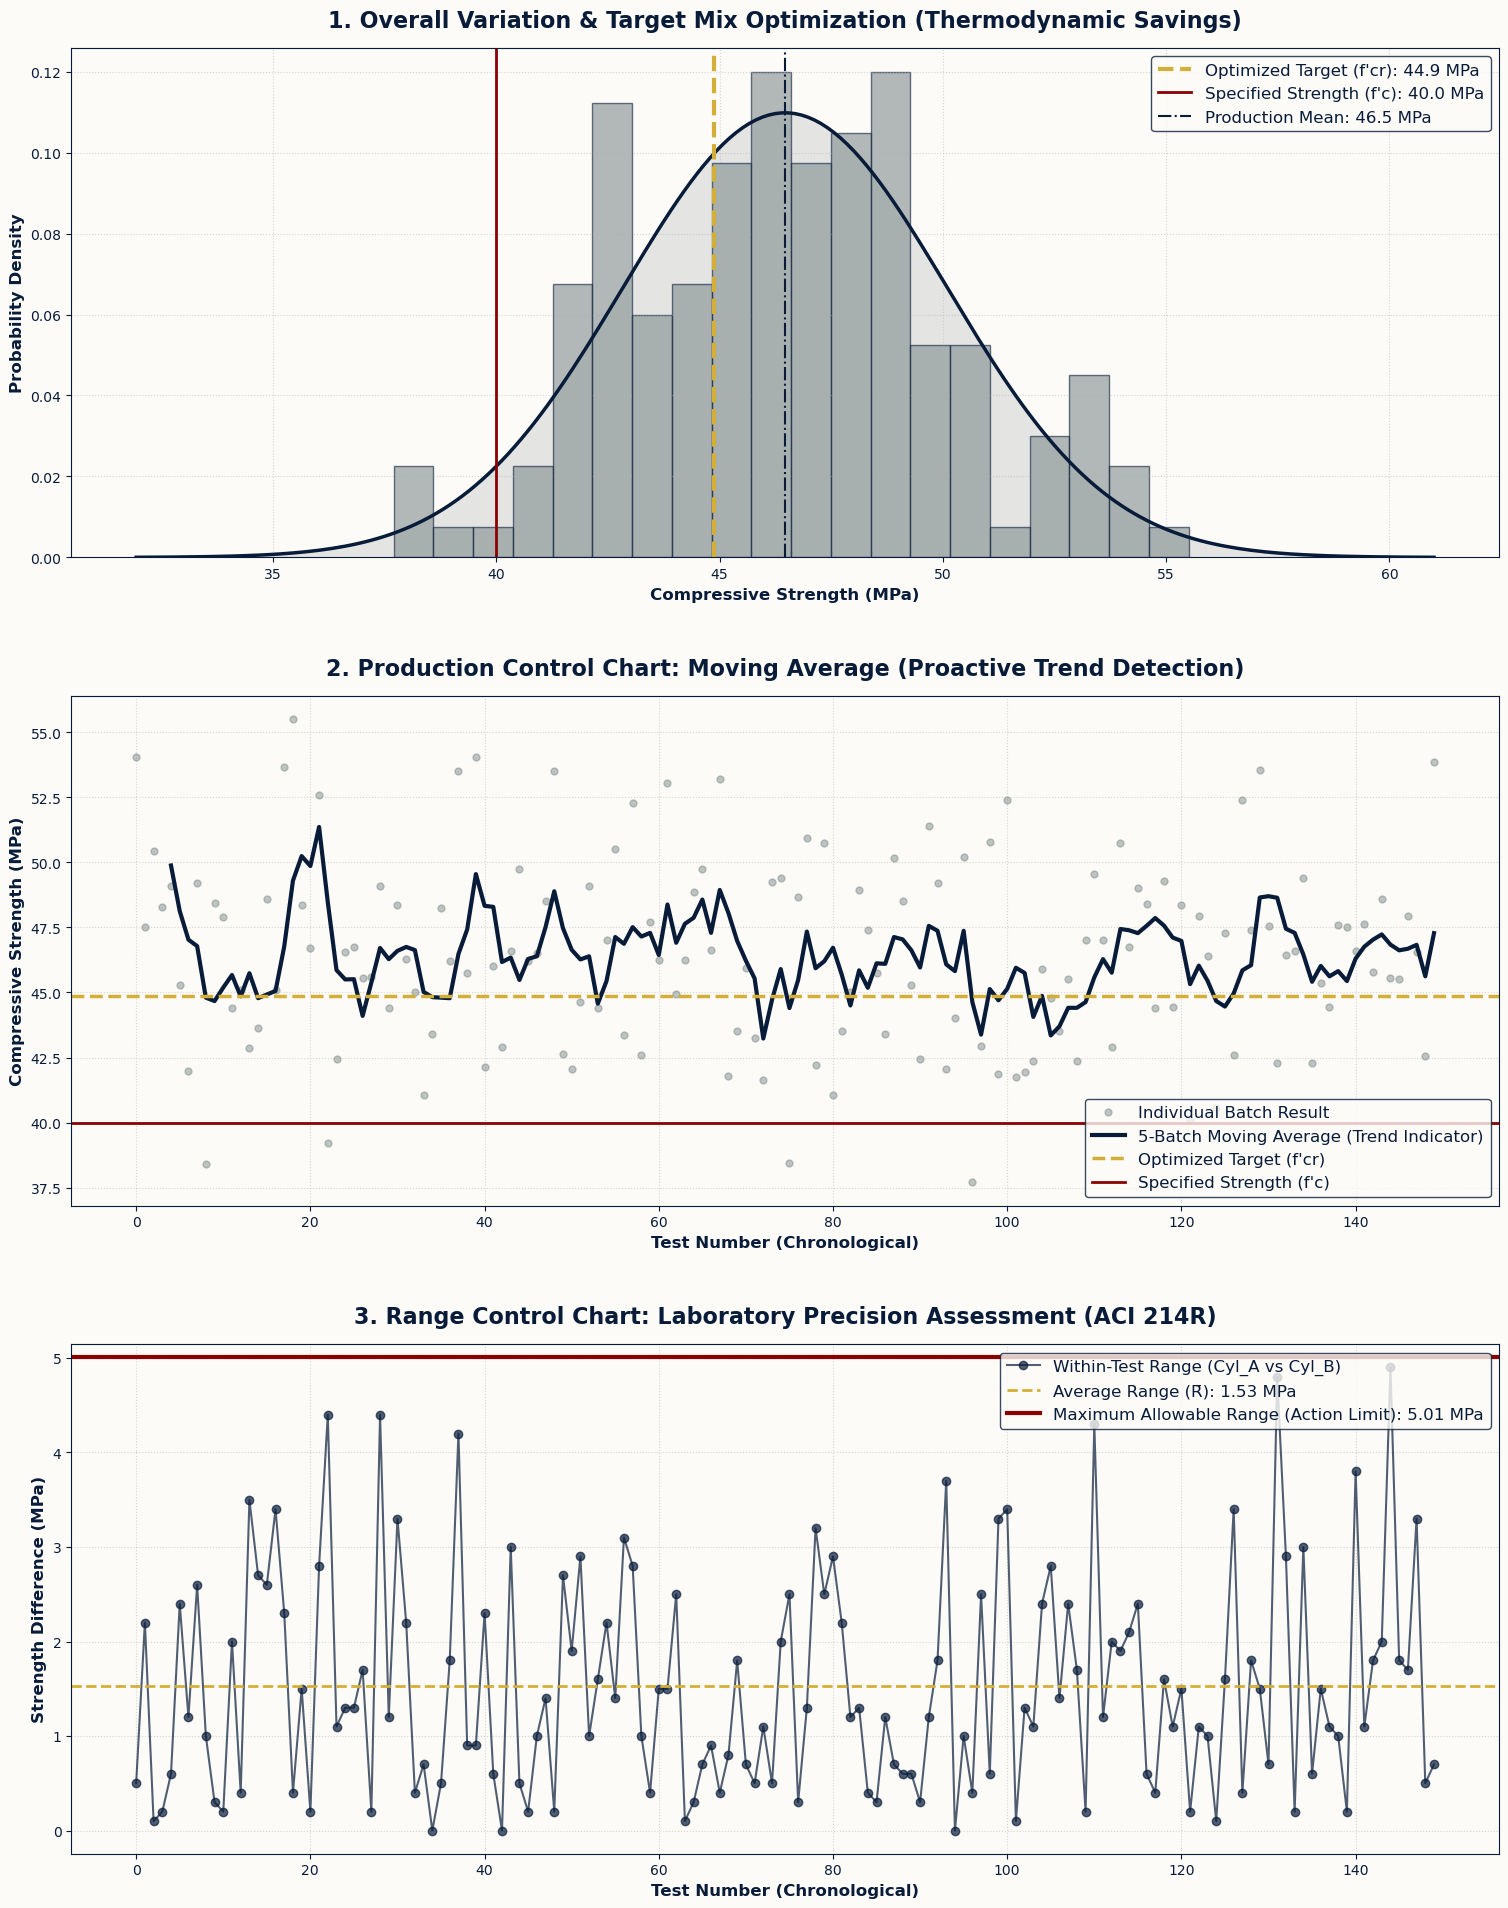


💡 EXECUTIVE SUMMARY (Engineering Certainty):
✔️ Overall Production Standard Deviation (Sc) : 3.63 MPa
✔️ Lab Precision Standard Deviation (S1)      : 1.36 MPa
✔️ Optimized Target Strength (f'cr)           : 44.87 MPa


In [18]:
# [Markdown]
# ## 4. Executive Dashboard Generation (Zero-Code Interface)
# **Instructions for the Engineer:**
# The engine will read from `QAQC_Concrete_Test_Records.csv`.
# Simply define your project's specified strength (f'c) below and run the cell.

PROJECT_FC_MPA = 40.0

# Initialize the Engine and Render Dashboards
nexus_engine = ACI214Engine(data=df_concrete, fc_specified=PROJECT_FC_MPA)
nexus_engine.render_dashboards()